<a href="https://colab.research.google.com/github/Bhavya-Chellapandian/Taxi-Data-Analysis-Pandas-Matplotlib-Seaborn/blob/main/Taxi_Data_Analysis_using_Pandas%2C_Matplotlib_%26_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Taxi Data Analysis using Pandas, Matplotlib & Seaborn

1.Import the Pandas,Matplotlib,Seaborn

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2.Load the Taxis Dataset


In [20]:
# Load the dataset
df = sns.load_dataset("taxis")
df.head()


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.00,2.15,0.00,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.00,0.00,0.00,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.50,2.36,0.00,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.00,6.15,0.00,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.00,1.10,0.00,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


3.Check Missing Values


In [26]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean()*100
})
missing_summary


,Missing Count,Missing Percentage
pickup,0,0.00
dropoff,0,0.00
passengers,0,0.00
distance,0,0.00
fare,0,0.00
tip,0,0.00
tolls,0,0.00
total,0,0.00
color,0,0.00
payment,44,0.68


4.Handle Missing Values

In [27]:
# Fill missing numerical columns
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

# Fill missing categorical columns
categorical_cols = df.select_dtypes(include=["object", "category"]).columns
for col in categorical_cols:
    if df[col].isna().any():
        mode_value = df[col].mode(dropna=True)
        if not mode_value.empty:
            df[col] = df[col].fillna(mode_value.iloc[0])

print("Missing-value handling completed.")


Missing-value handling completed.


In [28]:
# Verify missing values after cleaning
df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,0


5.Basic Visualizations

5.1 Line Chart – Fare Over Time


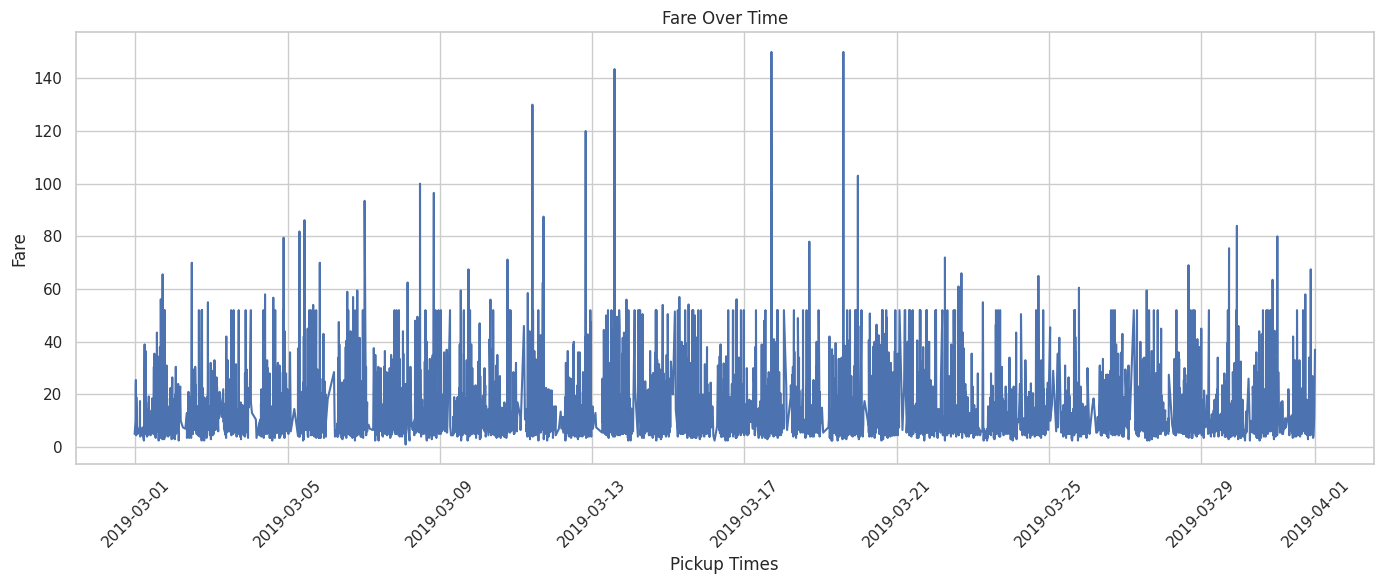

In [30]:
# Sort by pickup time before plotting
line_df = df.sort_values("pickup")

plt.figure(figsize=(14, 6))
plt.plot(line_df["pickup"], line_df["fare"])
plt.title("Fare Over Time")
plt.xlabel("Pickup Times")
plt.ylabel("Fare")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


5.2 Bar Chart – Total Fare by Pickup Borough

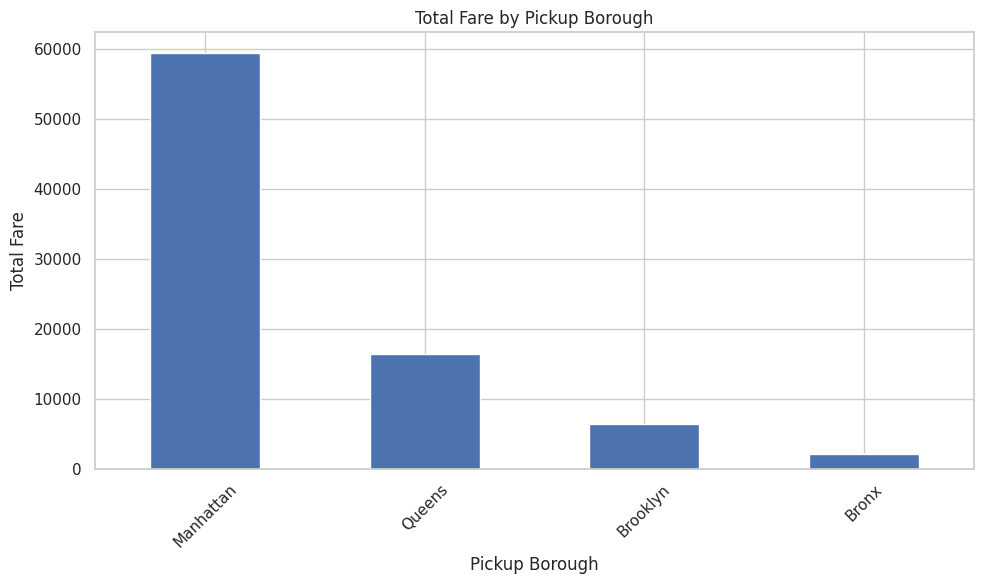

In [31]:
borough_fare = (df.groupby("pickup_borough", observed=True)["fare"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
borough_fare.plot(kind="bar")
plt.title("Total Fare by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


5.3 Pie Chart – Trips by Payment Method

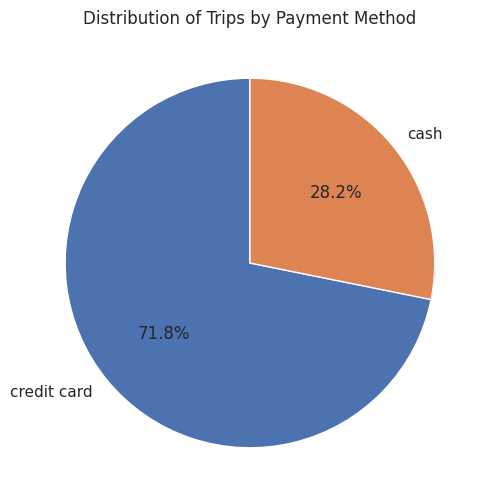

In [32]:
payment_counts = df["payment"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribution of Trips by Payment Method")
plt.show()


5.4 Histogram – Distance Distribution

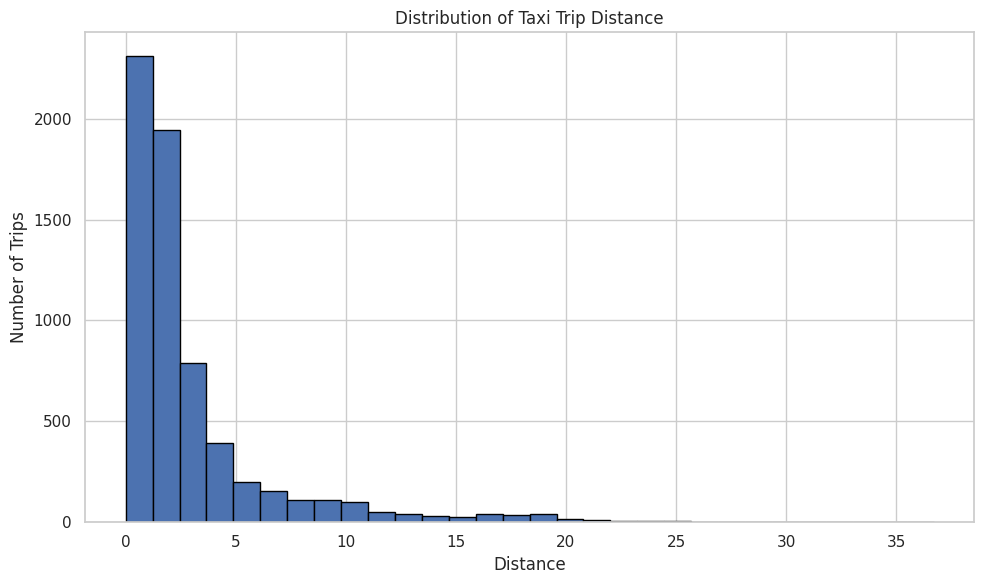

In [33]:
plt.figure(figsize=(10, 6))
plt.hist(df["distance"], bins=30, edgecolor="black")
plt.title("Distribution of Taxi Trip Distance")
plt.xlabel("Distance")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.show()


6.Statistical Visualization

6.1 Box Plot – Tip Amount by Pickup Borough

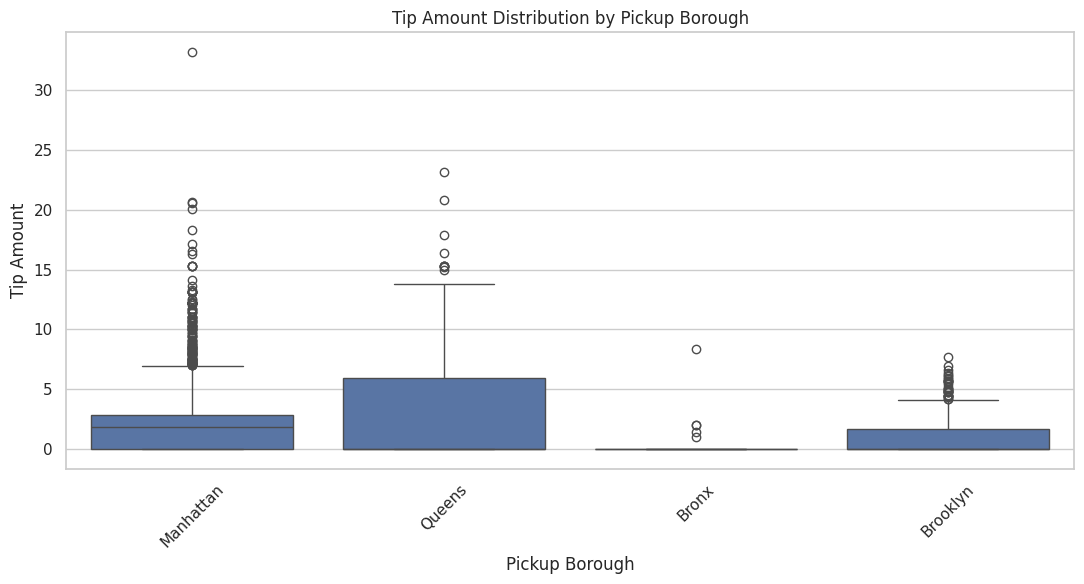

In [34]:
plt.figure(figsize=(11, 6))
sns.boxplot(data=df, x="pickup_borough", y="tip")
plt.title("Tip Amount Distribution by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Tip Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


6.2 Count Plot – Number of Trips by Pickup Borough

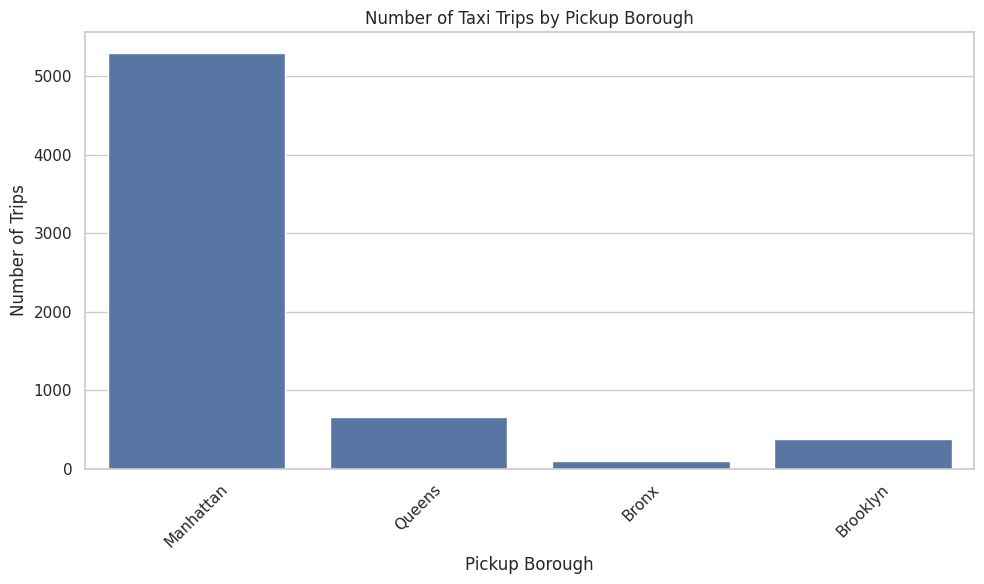

In [35]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="pickup_borough")
plt.title("Number of Taxi Trips by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


6.3 Scatter Plot – Distance vs Fare

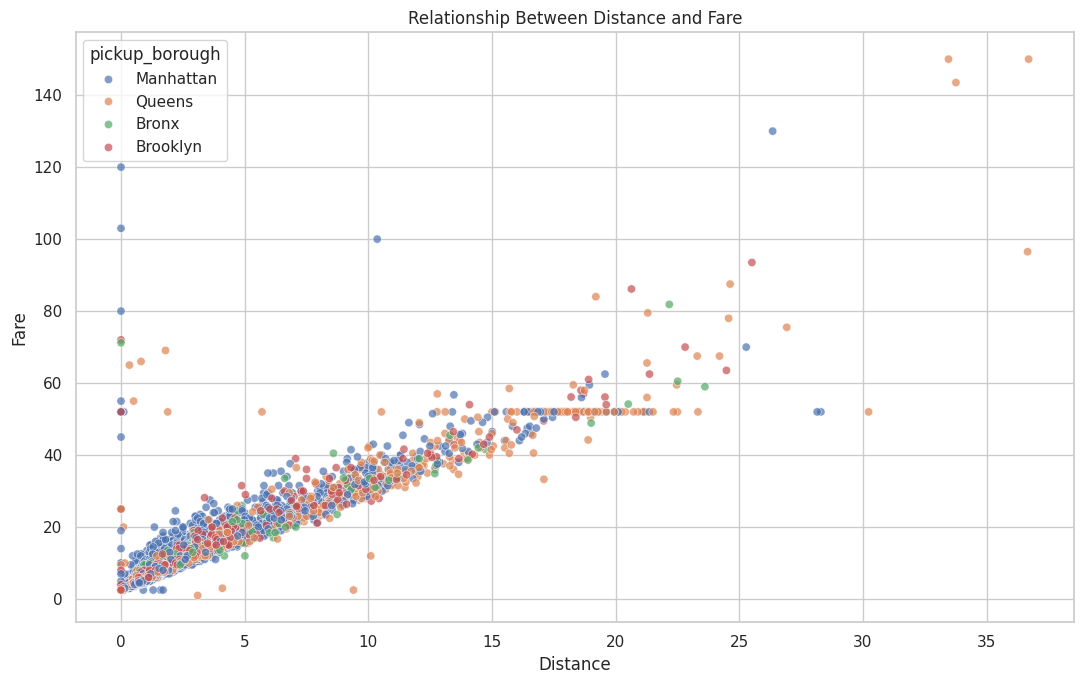

In [39]:
plt.figure(figsize=(11, 7))
sns.scatterplot(
    data= df,
    x="distance",
    y="fare",
    hue="pickup_borough",
    alpha=0.7
)
plt.title("Relationship Between Distance and Fare")
plt.xlabel("Distance")
plt.ylabel("Fare")
plt.tight_layout()
plt.show()


7.Advanced Visualization

7.1 Heatmap – Correlation Between Numerical Variables

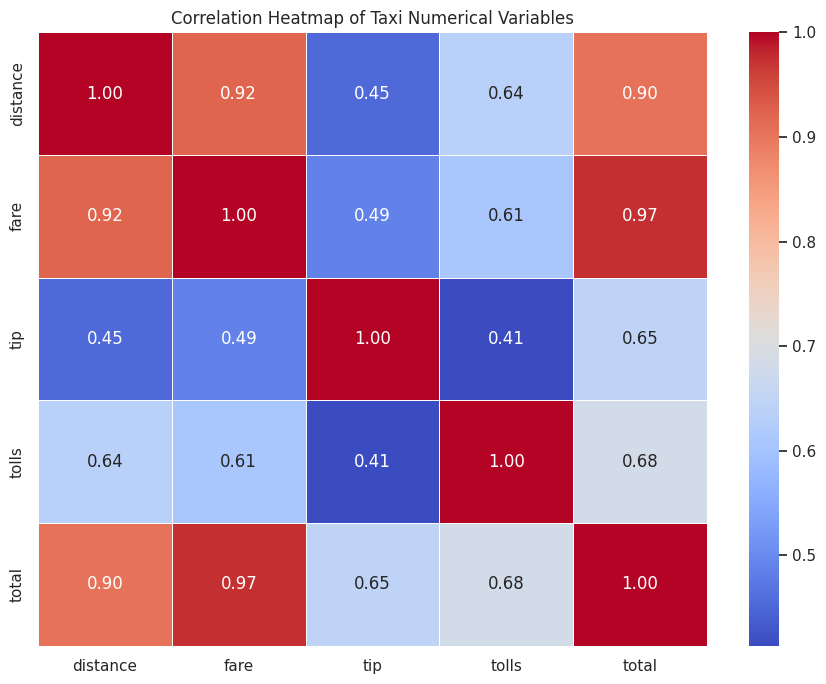

In [40]:
corr_cols = ["distance", "fare", "tip", "tolls", "total"]
correlation_matrix = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Taxi Numerical Variables")
plt.tight_layout()
plt.show()


7.2 Pair Plot – Distance, Fare, Tip and Total


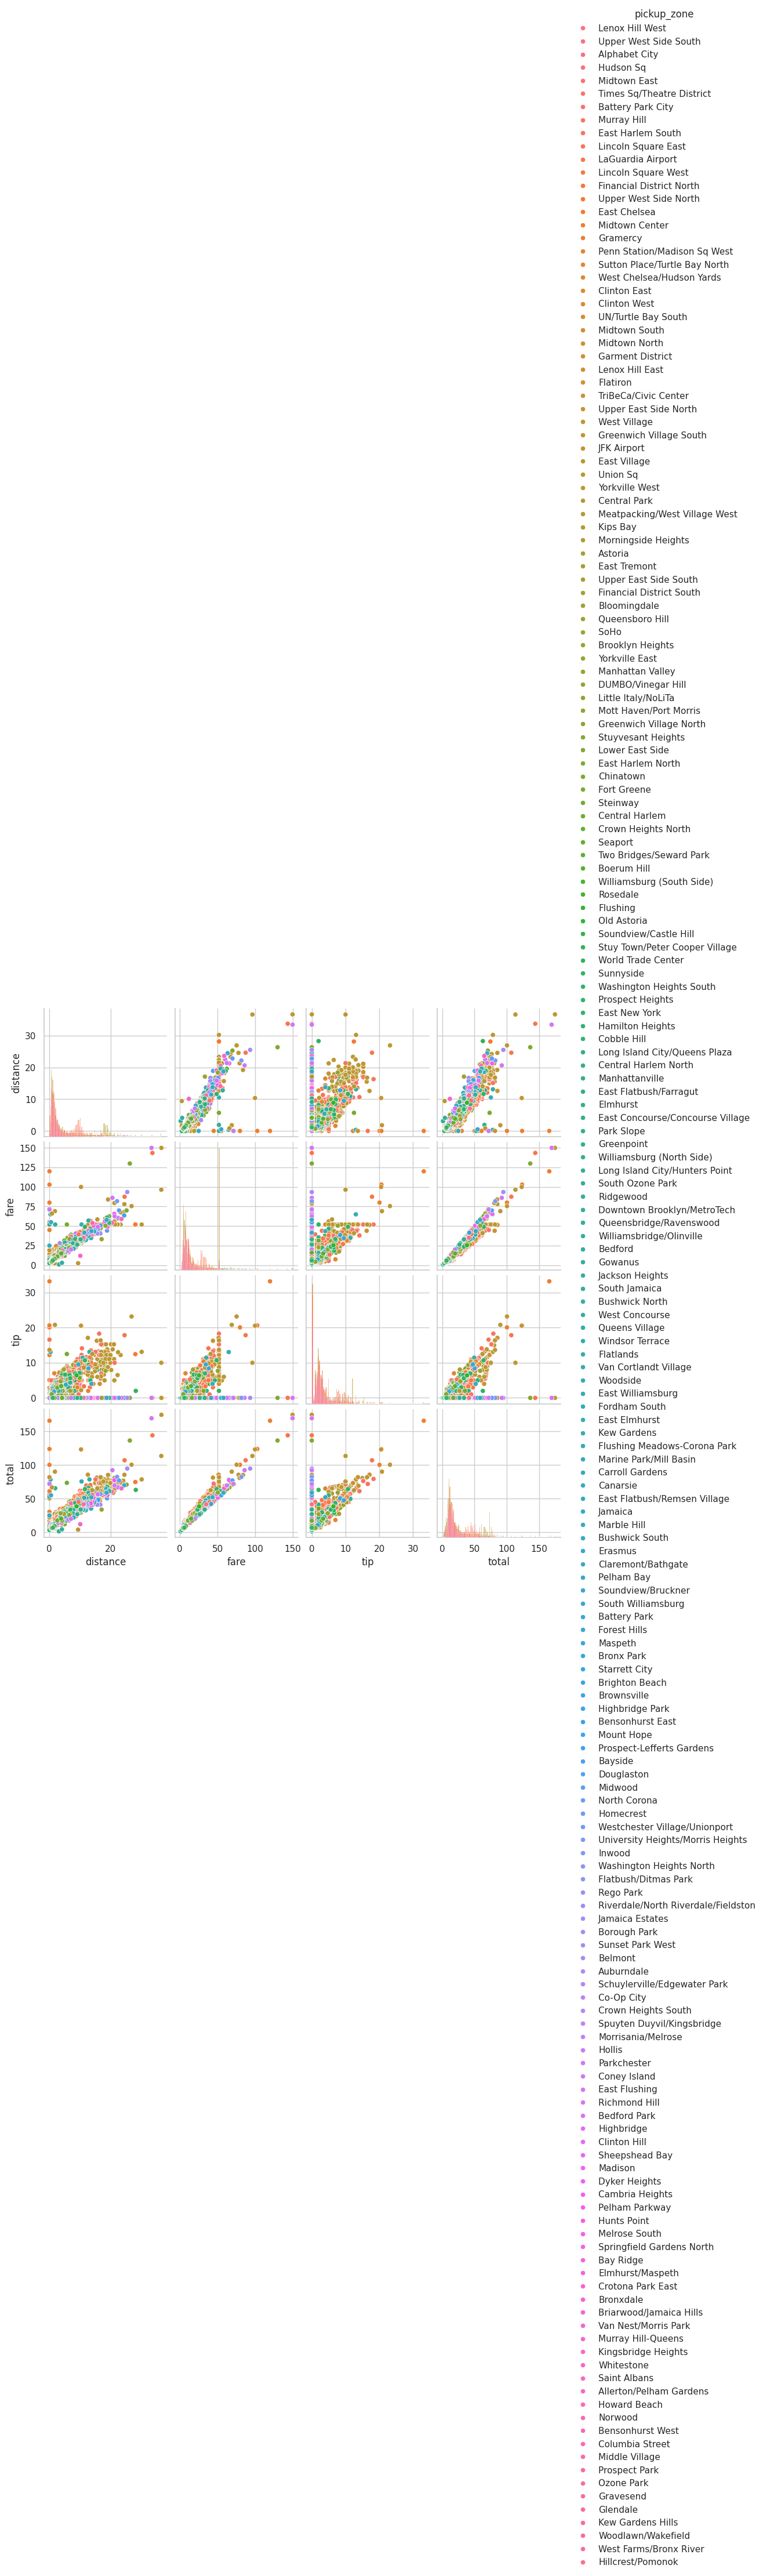

In [41]:
pair_cols = ["distance", "fare", "tip", "total", "pickup_zone"]

pair_df = df[pair_cols].dropna()

sns.pairplot(
    pair_df,
    vars=["distance", "fare", "tip", "total"],
    hue="pickup_zone",
    diag_kind="hist",
    corner=False
)

plt.show()


7.3 Violin Plot – Fare by Payment Method

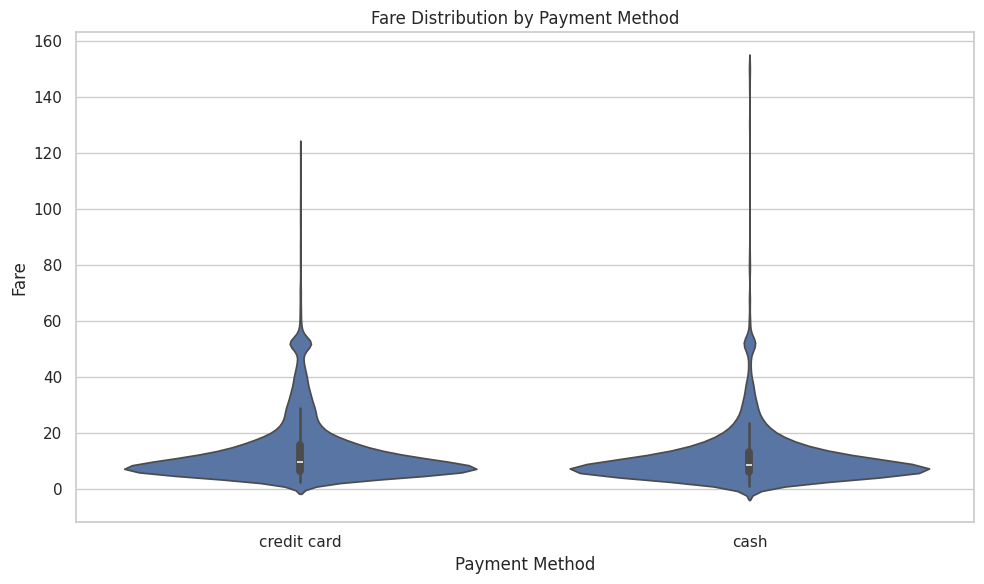

In [42]:
plt.figure(figsize=(10, 6))
sns.violinplot(
    data= df,
    x="payment",
    y="fare"
)
plt.title("Fare Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fare")
plt.tight_layout()
plt.show()
